<a href="https://colab.research.google.com/github/intuition-explorer/ML-Algorithms/blob/main/Chern_fullpipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Overfitting is not optimizing for minimizing (algo) complexity of explanation at hand
from google.colab import files
files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


{'WA_Fn-UseC_-Telco-Customer-Churn (1).csv': b'customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn\r\n7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No\r\n5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No\r\n3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes\r\n7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No\r\n9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes\r\n9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer #0,1,2,n-1
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape #21 features, 7043 samples
df.columns #here clean data, target is given
df.head()
y=df['Churn'].copy()
X=df.drop(['Churn', 'customerID'], axis =1 ).copy() # Added () to call the copy function
y= y.apply(lambda x: 0 if x=='No' else 1) #this makes it a classification problem
print(y.head())
print(y.value_counts())  # See imbalance here 1:3, but should SMOTE be used in general hmm

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum()) #only detects NaN or None, can be ' ' or other depends on domain!!
#can also use is unique to check
df['Partner'].unique()
df.info()
df['tenure'].unique()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   obj

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [ ]:
#Check all
for col in X.columns:
  print(col, X[col].unique()) #but may not be visible if lots of unique

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges ['29.85' '1889

In [ ]:
(df['TotalCharges'] == ' ') #goes in totalCharges column and returns Boolean mask of values, visually can only see FALSE
df[df['TotalCharges'] == ' '] #returns rows where that is TRUE= 11 rows I couldnt see out of 7000+
df[(df['TotalCharges'] == ' ') | (df['gender'] == ' ')] #here | is or, but id have to do this for all columns

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
#More generally it shows only whitespace/empty independnet of # of spaces
df[df['TotalCharges'].str.strip() == ''] #go in column, strip() removes leading & trailing whitespace cahracters

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
for col in df.columns:
    mask = df[col] == ' ' #Boolean mask created df[col]==' ', stored then as variable mask
    if mask.any():  # only print if we actually find something
        print(f"Column: {col}")
        print(df.loc[mask, col])

for col in df.columns:
    # only apply .str methods to object (string) columns
    if df[col].dtype == 'object':
        mask = df[col].str.strip() == ''
        if mask.any():
            print(f"Column: {col} has {mask.sum()} blank entries")
            print(df.loc[mask, col])  # shows the actual rows

Column: TotalCharges
488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object
Column: TotalCharges has 11 blank entries
488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object


In [ ]:
missing= [' ', '', 'na', 'NA', 'Na', 'n/a', 'N/A', 'null', 'NULL', 'Null', '?', '--', '-','none', 'None', 'NONE']
for col in X.columns:
  if X[col].dtype == 'object': #checks non number columns
   mask = X[col].str.strip().isin(missing) #defines a boollean mask using X[col] == ' ', strip() removes trailing/leading whitespace, isin specifies more
   if mask.any(): #returns TRUE, else will say False,
     print(f"Column: {col} has {mask.sum()} suspicious missing values")
     #print(X.loc[mask, col]) #.loc shows specific rows: 488, 753,936,1082,1340,3331,3826,4380,5218,6670,6754
     print(X.loc[mask, col].unique()) #.loc selects specific row with mask in col then outputs unique

Column: TotalCharges has 11 suspicious missing values
[' ']


In [ ]:
#no service have no otpion to buy so one hot encoding
#Contract Ordinal, feels like Internet service too....... can do both ordinal and one hot =hybrid, then pick based on model
#collinearity affects regression but can add regularization, overfitting due to increase variance but have enough samples, harder to interpret feature imp
#IN PRACTICE USE DIFF COLUMNS FOR MODELS AND SEE!!!

In [ ]:
#RUN FROM HERE AFTER FIRST 2 IF NEED

missing= [' ', '', 'na', 'NA', 'Na', 'n/a', 'N/A', 'null', 'NULL', 'Null', '?', '--', '-','none', 'None', 'NONE']

# Replace specified missing value strings with np.nan in all object columns of X
for col in X.columns:
  if X[col].dtype == 'object':
    X[col] = X[col].replace(missing, np.nan)

# Convert 'TotalCharges' to numeric, coercing errors to NaN
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')

# Check for null values in TotalCharges
print(X['TotalCharges'].isnull().sum())

11


In [ ]:
X['Contract_ord'] = X['Contract']
X['Contract_ose'] = X['Contract']
X['InternetService_ord'] = X['InternetService']
X['InternetService_ose'] = X['InternetService']
X.drop(['Contract', 'InternetService'], axis = 1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Contract_ord,Contract_ose,InternetService_ord,InternetService_ose
0,Female,0,Yes,No,1,No,No phone service,No,Yes,No,...,No,No,Yes,Electronic check,29.85,29.85,Month-to-month,Month-to-month,DSL,DSL
1,Male,0,No,No,34,Yes,No,Yes,No,Yes,...,No,No,No,Mailed check,56.95,1889.50,One year,One year,DSL,DSL
2,Male,0,No,No,2,Yes,No,Yes,Yes,No,...,No,No,Yes,Mailed check,53.85,108.15,Month-to-month,Month-to-month,DSL,DSL
3,Male,0,No,No,45,No,No phone service,Yes,No,Yes,...,No,No,No,Bank transfer (automatic),42.30,1840.75,One year,One year,DSL,DSL
4,Female,0,No,No,2,Yes,No,No,No,No,...,No,No,Yes,Electronic check,70.70,151.65,Month-to-month,Month-to-month,Fiber optic,Fiber optic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,Mailed check,84.80,1990.50,One year,One year,DSL,DSL
7039,Female,0,Yes,Yes,72,Yes,Yes,No,Yes,Yes,...,Yes,Yes,Yes,Credit card (automatic),103.20,7362.90,One year,One year,Fiber optic,Fiber optic
7040,Female,0,Yes,Yes,11,No,No phone service,Yes,No,No,...,No,No,Yes,Electronic check,29.60,346.45,Month-to-month,Month-to-month,DSL,DSL
7041,Male,1,Yes,No,4,Yes,Yes,No,No,No,...,No,No,Yes,Mailed check,74.40,306.60,Month-to-month,Month-to-month,Fiber optic,Fiber optic


In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

bin_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

oneshot_col = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaymentMethod']

add_oneshot_col= ['InternetService_ose', 'Contract_ose']
ord_cols = ['InternetService_ord', 'Contract_ord']

ord_mapping = [
    ['No', 'DSL', 'Fiber optic'],             # InternetService
    ['Month-to-month', 'One year', 'Two year']  # Contract
]

X['gender'] = X['gender'].map({'Female': 0, 'Male': 1})
for col in bin_cols:
    X[col] = X[col].map({'No': 0, 'Yes': 1})
#FeatureTransformer is not common for few columns, use this instead to make binary, limits to only cols specificed above so shouldnt impact ord/ose

In [ ]:
X.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Contract_ord,Contract_ose,InternetService_ord,InternetService_ose
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,Month-to-month,1,Electronic check,29.85,29.85,Month-to-month,Month-to-month,DSL,DSL
1,1,0,0,0,34,1,No,DSL,Yes,No,...,No,One year,0,Mailed check,56.95,1889.50,One year,One year,DSL,DSL
2,1,0,0,0,2,1,No,DSL,Yes,Yes,...,No,Month-to-month,1,Mailed check,53.85,108.15,Month-to-month,Month-to-month,DSL,DSL
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,...,No,One year,0,Bank transfer (automatic),42.30,1840.75,One year,One year,DSL,DSL
4,0,0,0,0,2,1,No,Fiber optic,No,No,...,No,Month-to-month,1,Electronic check,70.70,151.65,Month-to-month,Month-to-month,Fiber optic,Fiber optic


In [ ]:
#Production Grade, imputers for all is good practice
ordinal_transformer = OrdinalEncoder(categories=ord_mapping, handle_unknown='use_encoded_value', unknown_value=-1)

num_transformer = Pipeline(steps=[('impute',SimpleImputer(strategy='median')),
                            ('scale', StandardScaler())])

one_transformer = Pipeline(steps=[('impute',SimpleImputer(strategy='most_frequent')),
                            ('onehot', OneHotEncoder(drop=None, handle_unknown='ignore'))])

ord_transformer = Pipeline(steps=[('impute',SimpleImputer(strategy='most_frequent')),
                            ('ord', ordinal_transformer)])

preprocessing_ord = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('oneshot', one_transformer, oneshot_col),
    ('ord', ord_transformer, ord_cols)
])

preprocessing_ose = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('oneshot', one_transformer, oneshot_col+add_oneshot_col)
])

#I want both OHS and ORD for InternetServices and Contract so save them as two diff columns then put in transformer

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Contract_ord,Contract_ose,InternetService_ord,InternetService_ose
3738,1,0,0,0,35,0,No phone service,DSL,No,No,...,Yes,Month-to-month,0,Electronic check,49.20,1701.65,Month-to-month,Month-to-month,DSL,DSL
3151,1,0,1,1,15,1,No,Fiber optic,Yes,No,...,No,Month-to-month,0,Mailed check,75.10,1151.55,Month-to-month,Month-to-month,Fiber optic,Fiber optic
4860,1,0,1,1,13,0,No phone service,DSL,Yes,Yes,...,No,Two year,0,Mailed check,40.55,590.35,Two year,Two year,DSL,DSL
3867,0,0,1,0,26,1,No,DSL,No,Yes,...,Yes,Two year,1,Credit card (automatic),73.50,1905.70,Two year,Two year,DSL,DSL
3810,1,0,1,1,1,1,No,DSL,No,No,...,No,Month-to-month,0,Electronic check,44.55,44.55,Month-to-month,Month-to-month,DSL,DSL


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

lr_model_ose = Pipeline(steps=[('preprocessing', preprocessing_ose),
                        ('classifier', LogisticRegression(
                            random_state=42,
                            max_iter=1000,
                            C=1.0,
                            penalty='l2',
                            solver='liblinear'
                        ))])

lr_model_ord = Pipeline(steps=[('preprocessing', preprocessing_ord),
                        ('classifier', LogisticRegression(
                            random_state=42,
                            max_iter=1000,
                            C=1.0,
                            penalty='l2',
                            solver='liblinear'
                        ))])

#Sanity check:baseline, internally does fit on folds then gives metric per fold
scores = cross_val_score(lr_model_ose, X_train, y_train, cv=5, scoring="roc_auc")
print("Baseline OSE CV ROC-AUC:", scores.mean())

#Sanity check:baseline
scores = cross_val_score(lr_model_ord, X_train, y_train, cv=5, scoring="roc_auc")
print("Baseline ORD CV ROC-AUC:", scores.mean())

Baseline OSE CV ROC-AUC: 0.8439068650696875
Baseline ORD CV ROC-AUC: 0.8440322316016342


In [ ]:
#Production level model benchmarking
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold # Import StratifiedKFold

# Stratified CV for imbalanced churn dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, clf in models.items():
    pipe1 = Pipeline(steps=[("preprocessing", preprocessing_ose),
                           ("classifier", clf)])

    scores1 = cross_val_score(pipe1, X_train, y_train, cv=cv, scoring="roc_auc")
    results[name] = scores1.mean()

for name, score1 in results.items():
    print(f"{name}: ROC-AUC = {score1:.3f}")


Logistic Regression: ROC-AUC = 0.845
Naive Bayes: ROC-AUC = 0.820
Decision Tree: ROC-AUC = 0.667
Random Forest: ROC-AUC = 0.808
Gradient Boosting: ROC-AUC = 0.846
SVM: ROC-AUC = 0.789
KNN: ROC-AUC = 0.774


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Stratified CV for imbalanced churn dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

# Both encoders
encoders = {
    "OneHot": preprocessing_ose,
    "Ordinal": preprocessing_ord
}

results = {}

# Loop over encoders + models
for enc_name, encoder in encoders.items():
    for model_name, clf in models.items():
        pipe = Pipeline(steps=[
            ("preprocessing", encoder),
            ("classifier", clf)
        ])

        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
        results[(enc_name, model_name)] = (scores.mean(), scores.std())

# Print results nicely
for (enc_name, model_name), (mean, std) in results.items():
    print(f"{enc_name} + {model_name}: ROC-AUC = {mean:.3f} ± {std:.3f}")


OneHot + Logistic Regression: ROC-AUC = 0.845 ± 0.014
OneHot + Naive Bayes: ROC-AUC = 0.820 ± 0.013
OneHot + Decision Tree: ROC-AUC = 0.667 ± 0.009
OneHot + Random Forest: ROC-AUC = 0.808 ± 0.010
OneHot + Gradient Boosting: ROC-AUC = 0.846 ± 0.012
OneHot + SVM: ROC-AUC = 0.789 ± 0.018
OneHot + KNN: ROC-AUC = 0.774 ± 0.015
Ordinal + Logistic Regression: ROC-AUC = 0.845 ± 0.014
Ordinal + Naive Bayes: ROC-AUC = 0.816 ± 0.014
Ordinal + Decision Tree: ROC-AUC = 0.667 ± 0.008
Ordinal + Random Forest: ROC-AUC = 0.807 ± 0.013
Ordinal + Gradient Boosting: ROC-AUC = 0.846 ± 0.012
Ordinal + SVM: ROC-AUC = 0.788 ± 0.017
Ordinal + KNN: ROC-AUC = 0.768 ± 0.015


In [ ]:
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga'],        # solvers compatible with l1/l2
    'classifier__class_weight': [None, 'balanced']     # handle imbalance
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_ord= Pipeline(steps=[('prep', preprocessing_ord),
                              ('classifier', LogisticRegression(random_state =22, max_iter=1000))])

lr_ose= Pipeline(steps=[('prep', preprocessing_ose),
                              ('classifier', LogisticRegression(random_state =22, max_iter=1000))])
grid_ord = GridSearchCV(
    estimator=lr_ord,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_ose = GridSearchCV(
    estimator=lr_ose,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_ord.fit(X_train, y_train)
grid_ose.fit(X_train, y_train)

print("Ordinal encoding best params:", grid_ord.best_params_)
print("Ordinal encoding best ROC-AUC:", grid_ord.best_score_)

print("OHE encoding best params:", grid_ose.best_params_)
print("OHE encoding best ROC-AUC:", grid_ose.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Ordinal encoding best params: {'classifier__C': 100, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Ordinal encoding best ROC-AUC: 0.8451052647496281
OHE encoding best params: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
OHE encoding best ROC-AUC: 0.8449638282403786


In [ ]:
#Ordinal encoding best params: {'classifier__C': 100, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
#Ordinal encoding best ROC-AUC: 0.8451052647496281

best_lr_model_ord = Pipeline(steps=[('preprocessing', preprocessing_ord),
                        ('classifier', LogisticRegression(
                            random_state=42,
                            max_iter=1000,
                            C=100.0,
                            class_weight=None,
                            penalty='l2',
                            solver='saga'
                        ))])

best_lr_model_ord.fit(X_train, y_train)
y_pred_ord_prob = best_lr_model_ord.predict_proba(X_test)[:, 1] #extract only prob of positive class [:,1]
print(classification_report(y_test, best_lr_model_ord.predict(X_test)))
print(confusion_matrix(y_test, best_lr_model_ord.predict(X_test)))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_ord_prob)
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

[[915 120]
 [174 200]]
ROC-AUC: 0.839774987728952


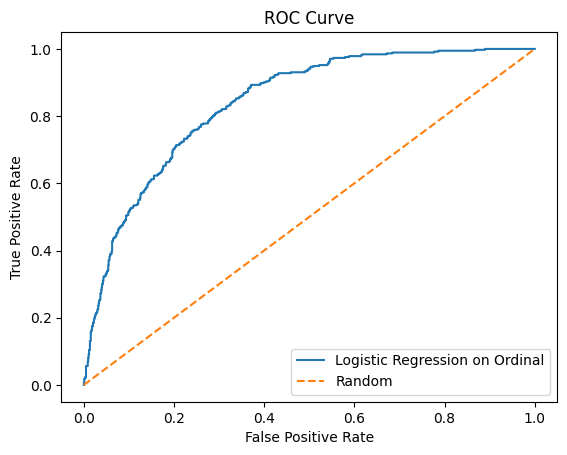

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
fpr, tpr, thresholds = roc_curve(y_test, y_pred_ord_prob) #roc_curve from metrics, takes binary true and predicted probab of + class
#fpr for diff thresholds incorrectlyl postive, tpr does for correct postives

#*Thresholds stores variables used to compute fpr and tpr, its the key to how this graph is generated

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')#this is 50% random shown
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(['Logistic Regression on Ordinal', 'Random'])
plt.show()


LogisticRegression(C=100.0, max_iter=1000, random_state=42, solver='saga')
[-1.28239715 -2.50997927  0.57622153 -0.36053583 -1.42040046  0.35919954
 -0.37362683 -0.62881792 -0.419292   -0.51257662 -0.62881792 -0.28034222
 -0.580972   -0.62881792 -0.21194683 -0.4064721  -0.62881792 -0.38644673
 -0.93241796 -0.62881792  0.13949913 -0.9328526  -0.62881792  0.13993377
 -0.46626646 -0.48846205 -0.0548587  -0.41214954  2.95248014 -0.74349306]


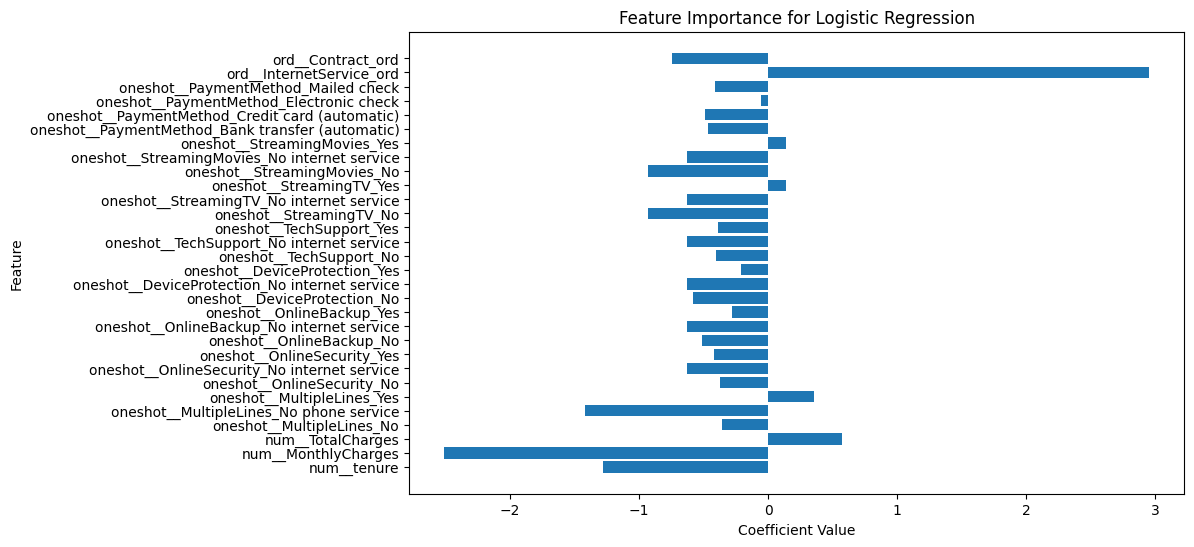

In [ ]:
#feature improtance
classifier = best_lr_model_ord.named_steps['classifier']
print(classifier)

coefs = classifier.coef_[0]  # 1D array for binary classification, coef assigned to each feature during training, would be 2d array [0] selects first row
print(coefs)

feature_names = best_lr_model_ord.named_steps['preprocessing'].get_feature_names_out()

plt.figure(figsize=(10, 6))
plt.barh(range(len(coefs)), coefs, align='center')
plt.yticks(range(len(coefs)), feature_names)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance for Logistic Regression')
plt.show()
# + increases probability of churn, - decreases

In [ ]:
# DEPLOYMENT NOW, THIS IS THE TRUE VALUE
import joblib
joblib.dump(best_lr_model_ord, 'best_lr_model_ord.pkl') #models state is saved to file, can load without having to retrain it

['best_lr_model_ord.pkl']

In [ ]:
loaded_model = joblib.load("best_lr_model_ord.pkl")
y_pred = loaded_model.predict(X_test)
y_pred_prob = loaded_model.predict_proba(X_test)[:,1]
#Testing if above reproduces

#then see if it can make predictios on new, this is the dynamic part. Feed new data and let it interact and make more predictions

POST /predict
{
  "gender": "Female",
  "tenure": 12,
  "InternetService": "Fiber optic",


}


SyntaxError: ':' expected after dictionary key (ipython-input-75785126.py, line 10)